# Fitted-profile source: fit-based sampler check

Ports/exercises `lucid.sources.fitted_profile_source` -- the composite `super_gauss * fermi_edge`
fit (PyROOT/Minuit2, run here in the job script) converted into a `MeasuredProfileSource`
(`is_collimator=False`) via `build_fit_cdf`. Duplicate of `measured_profile_source.ipynb`,
swapping the grid-backed sampler for the fit-backed one, to confirm the fit path works.

Everything here is validation-only. All the compute (fit -> build source -> sample -> validate)
runs in `fitted_profile_source_job.py` as a standalone process, same reasoning as
`measured_profile_source_job.py`: JAX/BLAS thread pools stay confined to that process. This
notebook only launches it and plots the results.

In [2]:
import sys

!{sys.executable} fitted_profile_source_job.py --out fitted_profile_source_results.npz


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
jax devices: [CpuDevice(id=0)] | backend: cpu | cpus: 4
WarwickDA02 (diffuser): w=39.07 p=1.14 a0=44.30 s=2.67  RSS=2.724e-03
WarwickCol_C01_repeat (collimator): w=2.74 p=5.57 a0=2.67 s=0.06  RSS=2.328e-02
saved results -> fitted_profile_source_results.npz


In [3]:
import numpy as np
import matplotlib.pyplot as plt

results = np.load('fitted_profile_source_results.npz', allow_pickle=True)
sample_ids = list(results['sample_ids'])


## Validate: fit-based sample vs profile-based sample vs measured (binned)

Three-way comparison on the true off-boresight angle `alpha` (same axis the fit was built on):
the raw measured+binned points `fit_common_profile` fit to, the already-validated grid-based
`measured_profile_source` sample, and the new `fitted_profile_source` sample -- both samples'
histograms are unfolded by the `sin(alpha)` solid-angle Jacobian. Computed in
`fitted_profile_source_job.py`; this cell only plots the saved arrays.

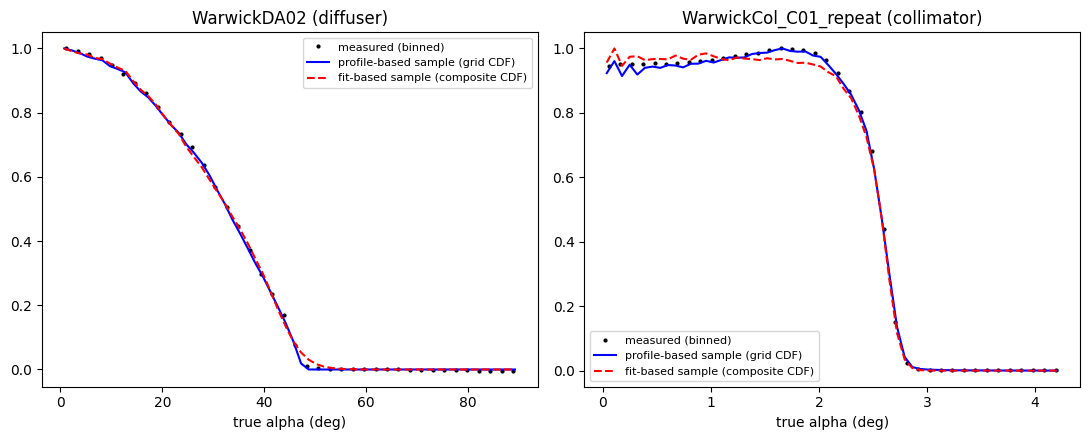

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, sample_id in zip(axes, sample_ids):
    device_type = str(results[f'{sample_id}__device_type'])
    measured_alpha = results[f'{sample_id}__measured_alpha']
    measured_intensity = results[f'{sample_id}__measured_intensity']
    centers = results[f'{sample_id}__centers']
    profile_density = results[f'{sample_id}__profile_density']
    fit_density = results[f'{sample_id}__fit_density']

    ax.plot(measured_alpha, measured_intensity, 'k.', ms=4, label='measured (binned)')
    ax.plot(centers, profile_density, 'b-', label='profile-based sample (grid CDF)')
    ax.plot(centers, fit_density, 'r--', label='fit-based sample (composite CDF)')
    ax.set_title(f'{sample_id} ({device_type})'); ax.set_xlabel('true alpha (deg)'); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()


## Validate: fit-based sample is uniform in phi

`fitted_profile_source` builds its CDF tables as phi-uniform (rank-1 in `u=cos(alpha)`) --
histogramming the sampled `phi` should come out flat, confirming that assumption actually
holds in the sampled rays and not just in the table construction. Computed in
`fitted_profile_source_job.py`; this cell only plots the saved arrays.

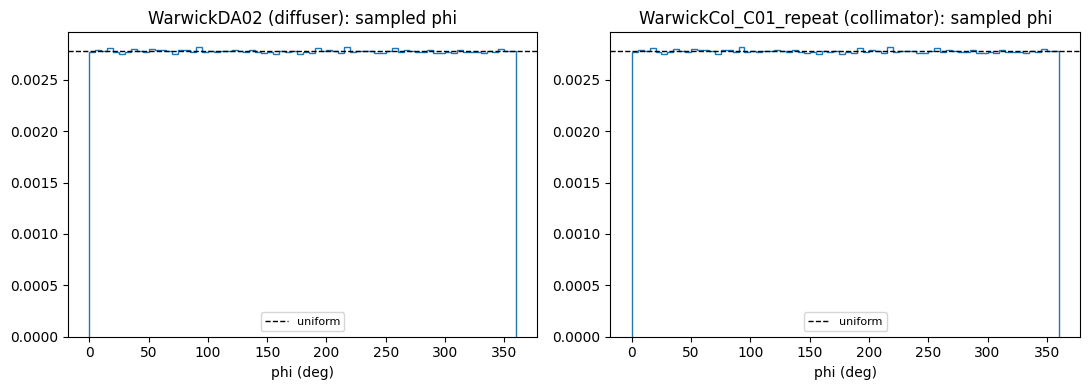

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
for ax, sample_id in zip(axes, sample_ids):
    device_type = str(results[f'{sample_id}__device_type'])
    phi_fit = results[f'{sample_id}__phi_fit']
    ax.hist(phi_fit, bins=72, histtype='step', density=True, lw=2)
    ax.axhline(1.0 / 360.0, color='k', ls='--', lw=1, label='uniform')
    ax.set_title(f'{sample_id} ({device_type}): sampled phi'); ax.set_xlabel('phi (deg)'); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()


## Validate: rotation preserves shape

Same PRNG key for a rotated and an un-rotated fit-based source draws the identical underlying
`(u, phi)` samples, just reoriented -- so the angle from each source's own axis should match
exactly. Computed in `fitted_profile_source_job.py`; this cell only plots the saved arrays.

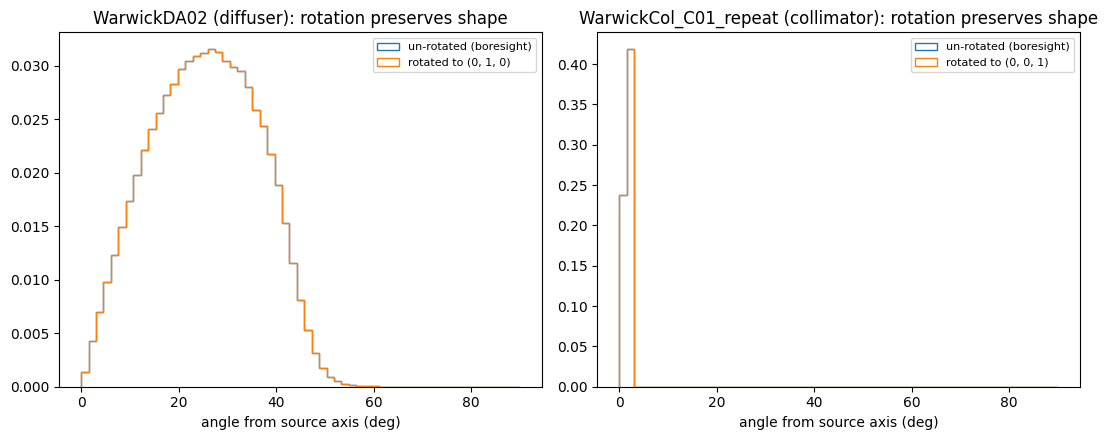

In [6]:
rotation_labels = {
    'WarwickDA02': 'rotated to (0, 1, 0)',
    'WarwickCol_C01_repeat': 'rotated to (0, 0, 1)',
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, sample_id in zip(axes, sample_ids):
    device_type = str(results[f'{sample_id}__device_type'])
    angle_from_boresight = results[f'{sample_id}__angle_from_boresight']
    angle_from_direction = results[f'{sample_id}__angle_from_direction']

    bins = np.linspace(0, 90, 60)
    ax.hist(angle_from_boresight, bins=bins, histtype='step', density=True, lw=2, label='un-rotated (boresight)')
    ax.hist(angle_from_direction, bins=bins, histtype='step', density=True, ls='--',
            label=rotation_labels[sample_id])
    ax.set_title(f'{sample_id} ({device_type}): rotation preserves shape')
    ax.set_xlabel('angle from source axis (deg)'); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()


## Validate: shared-frame virtual scan vs the analytic fit

Same idea as `measured_profile_source.ipynb`'s shared-frame check: rotate the source to point
at `(theta=90ish, phi=90ish)` in one common frame, away from either device's own pole, and
compare a JAX virtual scan against an independent reprojection. Here "native" is the analytic
composite fit evaluated directly at each shared-frame grid point's true off-boresight angle
(angle from `SHARED_DIRECTION`) -- no `griddata` needed, since the fit is a smooth function we
can evaluate anywhere, and it's phi-uniform by construction so there's no native
`(theta_raw, phi_raw)` grid to reproject in the first place. Computed in
`fitted_profile_source_job.py`; this cell only plots the saved arrays.

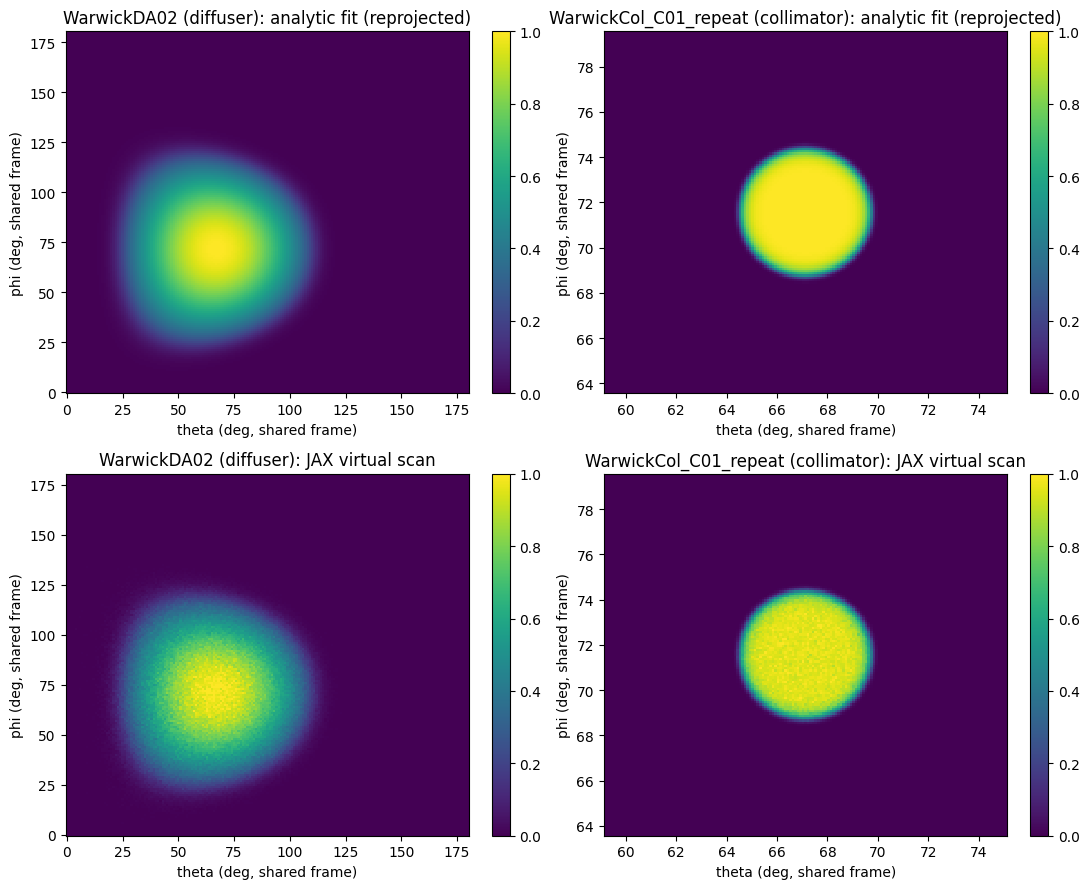

In [7]:
def profile_normalize(a, robust=False):
    a = np.asarray(a, dtype=float)
    valid = a[np.isfinite(a) & (a > 0)]
    peak = np.percentile(valid, 99.5) if robust else np.nanmax(a)
    return a / peak


boresight_theta = float(results['shared_boresight_theta'])
boresight_phi = float(results['shared_boresight_phi'])
# The collimator's fit is only a few degrees wide -- zoom in around the shared boresight so
# its disk is actually resolved, rather than a handful of pixels in a 0-180 view.
zoom_half_width = {'diffuser': None, 'collimator': 8.0}

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for col, sample_id in enumerate(sample_ids):
    device_type = str(results[f'{sample_id}__device_type'])
    theta_vals = results[f'{sample_id}__shared_theta_vals']
    phi_vals = results[f'{sample_id}__shared_phi_vals']
    scan_intensity = results[f'{sample_id}__shared_scan_intensity']
    native_intensity = results[f'{sample_id}__shared_native_intensity']

    native_norm = profile_normalize(native_intensity)
    scan_norm = profile_normalize(scan_intensity, robust=True)

    ax_native, ax_scan = axes[0, col], axes[1, col]
    mesh0 = ax_native.pcolormesh(theta_vals, phi_vals, native_norm, shading='nearest', vmin=0, vmax=1)
    ax_native.set_title(f'{sample_id} ({device_type}): analytic fit (reprojected)')
    fig.colorbar(mesh0, ax=ax_native, fraction=0.046)

    mesh1 = ax_scan.pcolormesh(theta_vals, phi_vals, scan_norm, shading='nearest', vmin=0, vmax=1)
    ax_scan.set_title(f'{sample_id} ({device_type}): JAX virtual scan')
    fig.colorbar(mesh1, ax=ax_scan, fraction=0.046)

    half_width = zoom_half_width[device_type]
    for ax in (ax_native, ax_scan):
        if half_width is not None:
            ax.set_xlim(boresight_theta - half_width, boresight_theta + half_width)
            ax.set_ylim(boresight_phi - half_width, boresight_phi + half_width)
        ax.set_xlabel('theta (deg, shared frame)'); ax.set_ylabel('phi (deg, shared frame)')
fig.tight_layout(); plt.show()
